In [3]:
# Import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/Airlines.csv')

# Show first 5 rows
df.head()


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [4]:
# How many rows and columns?
print(f"Dataset shape: {df.shape}")

# What are the column types?
print("\nColumn info:")
print(df.info())

# Any missing values?
print("\nMissing values:")
print(df.isnull().sum())






Dataset shape: (539383, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB
None

Missing values:
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


Delay distribution:
Delay
0    299119
1    240264
Name: count, dtype: int64

Delay percentage: 44.54%


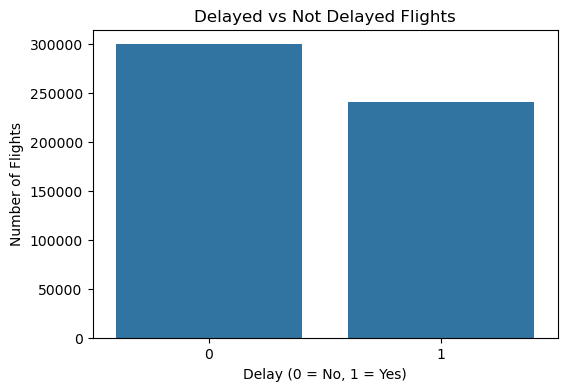

In [5]:
# How many delayed vs not delayed flights?
print("Delay distribution:")
print(df['Delay'].value_counts())

print(f"\nDelay percentage: {df['Delay'].mean() * 100:.2f}%")

# Visualize it
plt.figure(figsize=(6, 4))
sns.countplot(x='Delay', data=df)
plt.title('Delayed vs Not Delayed Flights')
plt.xlabel('Delay (0 = No, 1 = Yes)')
plt.ylabel('Number of Flights')
plt.show()

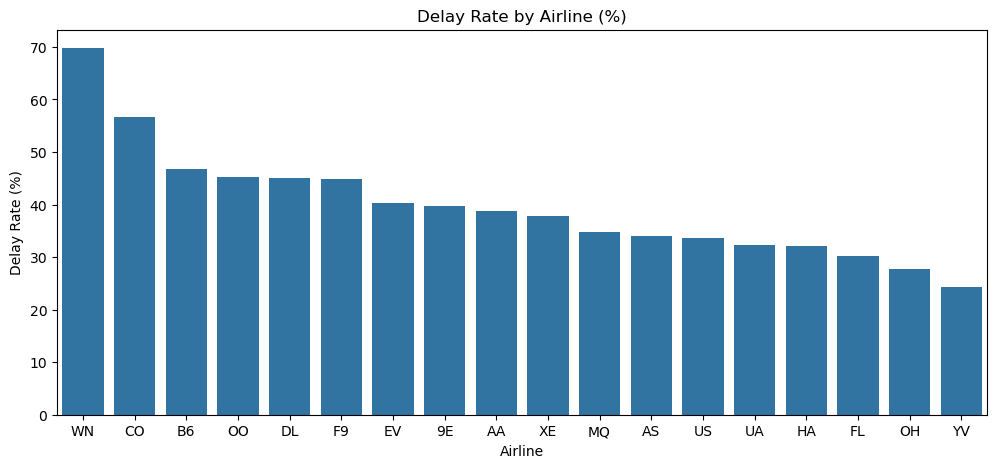

Airline
WN    69.775870
CO    56.619945
B6    46.703843
OO    45.289927
DL    45.047588
F9    44.903965
EV    40.220848
9E    39.766025
AA    38.847030
XE    37.894365
MQ    34.809452
AS    33.929038
US    33.597101
UA    32.390746
HA    32.018645
FL    30.129159
OH    27.727633
YV    24.291439
Name: Delay, dtype: float64


In [6]:
# Which airlines have the most delays?
airline_delays = df.groupby('Airline')['Delay'].mean() * 100
airline_delays = airline_delays.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=airline_delays.index, y=airline_delays.values)
plt.title('Delay Rate by Airline (%)')
plt.xlabel('Airline')
plt.ylabel('Delay Rate (%)')
plt.show()

print(airline_delays)

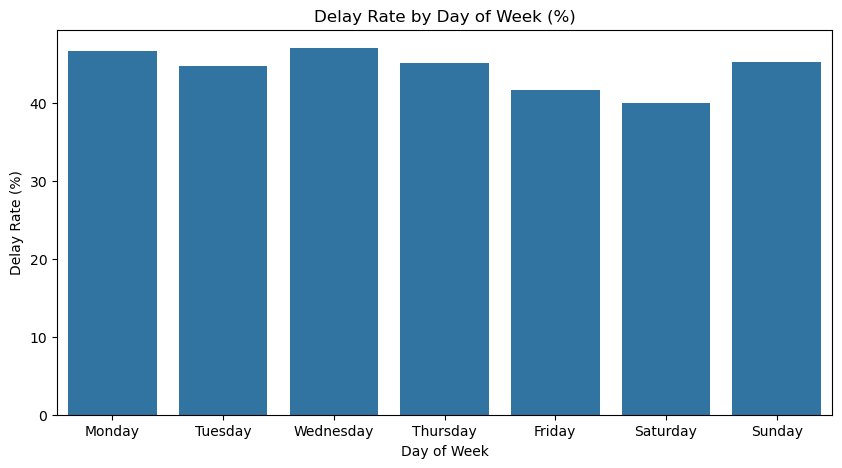

In [7]:
 # Which day of the week has most delays?
day_delays = df.groupby('DayOfWeek')['Delay'].mean() * 100

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(x=days, y=day_delays.values)
plt.title('Delay Rate by Day of Week (%)')
plt.xlabel('Day of Week')
plt.ylabel('Delay Rate (%)')
plt.show()


In [8]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare features
# Drop columns we don't need for prediction
X = df[['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length']]
y = df['Delay']

# Convert text columns to numbers
X = pd.get_dummies(X, columns=['Airline', 'AirportFrom', 'AirportTo'])

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")






Training set size: (431506, 607)
Testing set size: (107877, 607)


In [9]:
# Train Logistic Regression model
print("Training model... please wait")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Show results
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Results:")
print(classification_report(y_test, y_pred))

Training model... please wait


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model Accuracy: 64.37%

Detailed Results:
              precision    recall  f1-score   support

           0       0.65      0.78      0.71     59879
           1       0.63      0.48      0.54     47998

    accuracy                           0.64    107877
   macro avg       0.64      0.63      0.63    107877
weighted avg       0.64      0.64      0.63    107877



In [11]:

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
print("Training Random Forest... this may take 2-3 minutes")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Test the model
rf_pred = rf_model.predict(X_test)

# Show results
print(f"\nRandom Forest Accuracy: {accuracy_score(y_test, rf_pred) * 100:.2f}%")
print("\nDetailed Results:")
print(classification_report(y_test, rf_pred))


Training Random Forest... this may take 2-3 minutes

Random Forest Accuracy: 61.88%

Detailed Results:
              precision    recall  f1-score   support

           0       0.65      0.67      0.66     59879
           1       0.57      0.56      0.56     47998

    accuracy                           0.62    107877
   macro avg       0.61      0.61      0.61    107877
weighted avg       0.62      0.62      0.62    107877



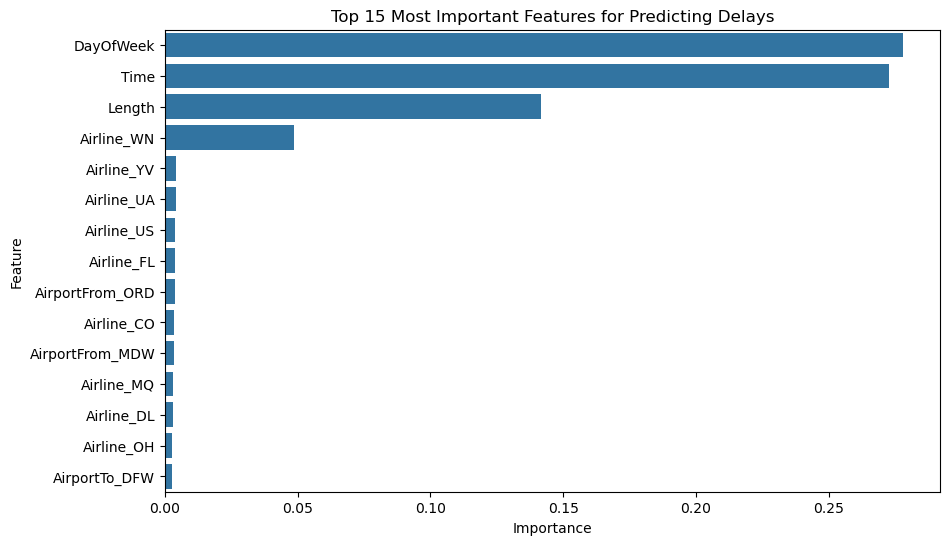

             feature  importance
0          DayOfWeek    0.278092
1               Time    0.272724
2             Length    0.141606
18        Airline_WN    0.048576
20        Airline_YV    0.004066
16        Airline_UA    0.004010
17        Airline_US    0.003806
11        Airline_FL    0.003730
229  AirportFrom_ORD    0.003586
7         Airline_CO    0.003452
196  AirportFrom_MDW    0.003271
13        Airline_MQ    0.002916
8         Airline_DL    0.002858
14        Airline_OH    0.002774
394    AirportTo_DFW    0.002714


In [12]:
# Show feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Top 15 Most Important Features for Predicting Delays')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print(feature_importance)

In [13]:


df2 = df.copy()

# 1. Time of Day — Morning/Afternoon/Evening/Night
def time_of_day(time):
    if time < 600:
        return 'Night'
    elif time < 1200:
        return 'Morning'
    elif time < 1800:
        return 'Afternoon'
    else:
        return 'Evening'

df2['TimeOfDay'] = df2['Time'].apply(time_of_day)

# 2. Rush Hour — 7-9am or 5-7pm
df2['IsRushHour'] = df2['Time'].apply(lambda x: 1 if (700 <= x <= 900) or (1700 <= x <= 1900) else 0)

# 3. Late Night flight
df2['IsLateNight'] = df2['Time'].apply(lambda x: 1 if x >= 2200 else 0)

# 4. Is Weekend
df2['IsWeekend'] = df2['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)

# 5. Flight Length Category
def flight_category(length):
    if length < 120:
        return 'Short'
    elif length < 240:
        return 'Medium'
    else:
        return 'Long'

df2['FlightCategory'] = df2['Length'].apply(flight_category)

# 6. Is Busy Airport (top 10 busiest US airports)
busy_airports = ['ATL', 'LAX', 'ORD', 'DFW', 'DEN', 'JFK', 'SFO', 'LAS', 'PHX', 'IAH']
df2['IsBusyAirport'] = df2['AirportFrom'].apply(lambda x: 1 if x in busy_airports else 0)

# 7. Route — combine departure and arrival airport
df2['Route'] = df2['AirportFrom'] + '_' + df2['AirportTo']

print("New features created successfully!")
print(f"\nNew columns added:")
new_cols = ['TimeOfDay', 'IsRushHour', 'IsLateNight', 'IsWeekend', 'FlightCategory', 'IsBusyAirport', 'Route']
for col in new_cols:
    print(f"  ✅ {col}")

print(f"\nSample of new data:")
df2[new_cols].head()

New features created successfully!

New columns added:
  ✅ TimeOfDay
  ✅ IsRushHour
  ✅ IsLateNight
  ✅ IsWeekend
  ✅ FlightCategory
  ✅ IsBusyAirport
  ✅ Route

Sample of new data:


,TimeOfDay,IsRushHour,IsLateNight,IsWeekend,FlightCategory,IsBusyAirport,Route
0,Night,0,0,0,Medium,1,SFO_IAH
1,Night,0,0,0,Medium,1,PHX_CLT
2,Night,0,0,0,Medium,1,LAX_DFW
3,Night,0,0,0,Medium,1,SFO_DFW
4,Night,0,0,0,Medium,0,ANC_SEA


In [16]:
# ============================================
# RETRAIN MODEL 
# ============================================

# Drop Route column — too many unique values slows everything down
X2 = df2[['DayOfWeek', 'Time', 'Length', 'IsRushHour', 
           'IsLateNight', 'IsWeekend', 'IsBusyAirport',
           'Airline', 'TimeOfDay', 'FlightCategory']]

y2 = df2['Delay']

# Convert text columns to numbers
X2 = pd.get_dummies(X2, columns=['Airline', 'TimeOfDay', 'FlightCategory'])

# Split data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train Random Forest
print("Training improved model... please wait")
rf_model2 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model2.fit(X2_train, y2_train)

# Results
rf_pred2 = rf_model2.predict(X2_test)
print(f"\nOriginal Model Accuracy: 61.88%")
print(f"Improved Model Accuracy: {accuracy_score(y2_test, rf_pred2) * 100:.2f}%")

Training improved model... please wait

Original Model Accuracy: 61.88%
Improved Model Accuracy: 61.29%
